
# Sesión 3 — Árboles de Decisión, Métodos de Ensamble y Desbalance de Clases

**Curso de Machine Learning — Maestría en Ciencia de Datos y Analítica (MCDA), EAFIT**

## Objetivos de la sesión

Al terminar esta sesión el estudiante debe ser capaz de:

1. Explicar cómo un árbol de decisión particiona el espacio de entrada y cómo
   se elige cada corte (split) usando Gini o Entropía (clasificación) o varianza
   (regresión).
2. Explicar la diferencia conceptual entre **bagging** y **boosting**, y cuándo
   cada uno reduce sesgo y/o varianza.
3. Entrenar y comparar `DecisionTreeClassifier`, `RandomForestClassifier` y
   `HistGradientBoostingClassifier` de scikit-learn sobre un problema real.
4. Ajustar hiperparámetros con `RandomizedSearchCV` y entender conceptualmente
   por qué existen alternativas más eficientes (optimización bayesiana / Optuna).
5. Reconocer por qué **accuracy es una métrica engañosa** en problemas con
   clases desbalanceadas, y aplicar técnicas simples de balanceo
   (undersampling, oversampling, Tomek Links) evaluando con métricas
   apropiadas (F1, recall, PR-AUC).

## Dataset de la clase

Vamos a trabajar con el dataset **Credit Card Fraud Detection** (Universidad
Libre de Bruselas, ULB), el ejemplo clásico de clasificación con desbalance
extremo de clases: transacciones con tarjeta de crédito, donde el objetivo es
detectar transacciones fraudulentas (clase minoritaria, `Class = 1`).

> **Nota sobre el submuestreo:** el dataset original tiene 284,807 filas
> (~150 MB en CSV), demasiado pesado para ejecutar en clase o para comitear al
> repositorio del curso. Más abajo hacemos un **submuestreo**: conservamos
> **todos** los casos de fraude y una muestra aleatoria de las transacciones
> normales, de forma que el dataset de trabajo queda en ~20,500 filas pero
> sigue siendo fuertemente desbalanceado (~2.4% positivos), preservando el
> reto pedagógico original.

---


## Preparación: librerías

In [1]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (7, 5)



## 1. Árboles de decisión

### 1.1 Idea general

Un árbol de decisión **particiona el espacio de entrada** (el espacio de las
variables predictoras) en regiones rectangulares disjuntas, mediante una
secuencia de preguntas binarias del tipo `¿variable_j <= umbral?`. Cada región
resultante (hoja del árbol) recibe una **predicción constante**:

- En **regresión**: el promedio de `y` de las observaciones que caen en esa
  hoja.
- En **clasificación**: la clase mayoritaria (o la distribución de
  probabilidades) de las observaciones que caen en esa hoja.

El árbol se construye de forma **greedy** (voraz): en cada nodo se busca la
variable y el umbral que producen la mejor mejora en una **función de costo**,
sin garantizar que la secuencia completa de splits sea globalmente óptima.

### 1.2 Función de costo

**Regresión — varianza / MSE dentro del nodo.** Para un nodo con
observaciones $\{y_i\}$, el costo es la varianza (equivalente a MSE respecto
a la media del nodo):

$$
\text{MSE}(\text{nodo}) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \bar{y})^2
$$

Se busca el split que minimiza el promedio ponderado del MSE de los dos nodos
hijos.

**Clasificación — Índice de Gini.** Sea $p_j$ la proporción de observaciones
de la clase $j$ en el nodo:

$$
\text{Gini} = 1 - \sum_{j} p_j^2
$$

- Gini = 0 → nodo perfectamente puro (una sola clase).
- Gini más alto → más mezcla de clases.
- **Menor Gini = mayor pureza.** El árbol busca el split que más reduce el
  Gini promedio (ponderado por tamaño) de los nodos hijos respecto al nodo
  padre.

**Clasificación — Entropía y ganancia de información.**

$$
\text{Entropía} = - \sum_{j} p_j \log_2(p_j)
$$

- Entropía = 0 → nodo puro.
- **Mayor entropía = mayor desorden = menor ganancia de información** al usar
  ese split.
- La **ganancia de información** de un split es la reducción de entropía del
  padre respecto al promedio ponderado de entropía de los hijos.

Gini y Entropía suelen dar árboles muy similares en la práctica; Gini es
ligeramente más rápida de calcular (no requiere logaritmos) y es el default
en scikit-learn.

### 1.3 Ejemplo pequeño: ¿jugamos fútbol según el clima?

Para ilustrar cómo se elige la variable/split en un nodo, construimos a mano
un dataset diminuto (versión simplificada del clásico ejemplo de libros de
texto de árboles de decisión).


In [2]:

futbol = pd.DataFrame({
    "clima": ["soleado", "soleado", "nublado", "lluvia", "lluvia", "lluvia",
              "nublado", "soleado", "soleado", "lluvia", "soleado", "nublado",
              "nublado", "lluvia"],
    "viento": ["debil", "fuerte", "debil", "debil", "debil", "fuerte",
               "fuerte", "debil", "debil", "debil", "fuerte", "fuerte",
               "debil", "fuerte"],
    "juega": ["no", "no", "si", "si", "si", "no", "si", "no", "si", "si",
              "si", "si", "si", "no"],
})
futbol


,clima,viento,juega
0,soleado,debil,no
1,soleado,fuerte,no
2,nublado,debil,si
3,lluvia,debil,si
4,lluvia,debil,si
5,lluvia,fuerte,no
6,nublado,fuerte,si
7,soleado,debil,no
8,soleado,debil,si
9,lluvia,debil,si



Calculemos el Gini del nodo raíz (sin ningún split) y comparémoslo con el
Gini ponderado que resulta de partir por `clima` vs. por `viento`. La
variable que produzca **mayor reducción de Gini** es la que el árbol elegiría
para el primer split.


In [3]:

def gini(serie):
    p = serie.value_counts(normalize=True)
    return 1 - np.sum(p ** 2)

def gini_ponderado(df, variable, objetivo="juega"):
    total = len(df)
    costo = 0.0
    for valor, grupo in df.groupby(variable):
        costo += (len(grupo) / total) * gini(grupo[objetivo])
    return costo

gini_raiz = gini(futbol["juega"])
gini_clima = gini_ponderado(futbol, "clima")
gini_viento = gini_ponderado(futbol, "viento")

print(f"Gini del nodo raíz (sin split):      {gini_raiz:.3f}")
print(f"Gini ponderado al partir por clima:   {gini_clima:.3f}  -> reducción = {gini_raiz - gini_clima:.3f}")
print(f"Gini ponderado al partir por viento:  {gini_viento:.3f}  -> reducción = {gini_raiz - gini_viento:.3f}")


Gini del nodo raíz (sin split):      0.459
Gini ponderado al partir por clima:   0.343  -> reducción = 0.116
Gini ponderado al partir por viento:  0.429  -> reducción = 0.031



`clima` produce mayor reducción de Gini que `viento`, así que el árbol
elegiría `clima` como primer split. Esto es exactamente lo que hace
`DecisionTreeClassifier(criterion="gini")` internamente, pero evaluando
**todas** las variables y **todos** los posibles umbrales en variables
continuas, en cada nodo, de forma recursiva.

### 1.4 Ventajas de los árboles

- **Interpretables**: se pueden visualizar y explicar a alguien no técnico
  (ej. "si la variable X es mayor que Y, entonces...").
- **No requieren normalización/escalado** de variables: las decisiones se
  basan en umbrales, no en distancias.
- **Manejan variables continuas y categóricas** de forma natural, y no
  asumen ninguna forma funcional (lineal, etc.) de la relación entre `X` y
  `y`.

### 1.5 Regularización: pre-pruning vs. post-pruning

Un árbol sin restricciones puede crecer hasta tener una hoja por cada
observación de entrenamiento → **overfitting** total (varianza altísima).
Dos estrategias para controlarlo:

- **Pre-pruning** (poda anticipada): limitar la complejidad *mientras* se
  construye el árbol, mediante hiperparámetros como `max_depth`,
  `min_samples_split`, `min_samples_leaf`, `max_leaf_nodes`.
- **Post-pruning** (poda posterior): dejar crecer el árbol completo y luego
  **podar** ramas que no aportan suficiente reducción de costo en un set de
  validación (ej. *cost-complexity pruning*, disponible en scikit-learn como
  `ccp_alpha`).

En la práctica, con datasets grandes, el pre-pruning (controlar
`max_depth` y compañía) es la estrategia más usada por su simplicidad y
menor costo computacional.

---

## 1.6 Cargando el dataset real: Credit Card Fraud Detection


In [4]:

# Este fetch descarga (o usa caché local) el dataset completo de OpenML.
# Puede tardar uno o varios minutos la primera vez.
d = fetch_openml("creditcard", version=1, as_frame=True, parser="auto")
df_full = d.frame

print("Shape del dataset ORIGINAL (completo):", df_full.shape)
print(df_full["Class"].value_counts())


Shape del dataset ORIGINAL (completo): (284807, 30)
Class
0    284315
1       492
Name: count, dtype: int64



El dataset completo tiene **284,807 filas** y las columnas `V1`...`V28` (28
componentes obtenidas por PCA sobre las variables originales, anonimizadas
por confidencialidad), `Amount` (monto de la transacción) y `Class` (la
variable objetivo: `1` = fraude, `0` = transacción normal). Solo **492**
transacciones (0.17%) son fraude: un desbalance extremo.

### Submuestreo para la clase

Nos quedamos con:

- **Todos** los casos de fraude (`Class == 1`): 492 filas.
- Una muestra aleatoria (`random_state=42`) de **20,000** transacciones
  normales (`Class == 0`).

El resultado es un dataset de ~20,500 filas que sigue siendo fuertemente
desbalanceado (~2.4% positivos) — suficiente para ilustrar todas las
técnicas de esta sesión sin descargar/comitear 150 MB de datos.


In [5]:

df_full["Class"] = df_full["Class"].astype(int)

fraude = df_full[df_full["Class"] == 1]
no_fraude = df_full[df_full["Class"] == 0].sample(n=20_000, random_state=RANDOM_STATE)

df = pd.concat([fraude, no_fraude], axis=0).sample(frac=1.0, random_state=RANDOM_STATE)
df = df.reset_index(drop=True)

print("Shape del dataset SUBMUESTREADO para la clase:", df.shape)
print(df["Class"].value_counts())
print(f"Porcentaje de fraude: {100 * df['Class'].mean():.2f}%")
df.head()


Shape del dataset SUBMUESTREADO para la clase: (20492, 30)
Class
0    20000
1      492
Name: count, dtype: int64
Porcentaje de fraude: 2.40%


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,1.193234,0.192237,0.410407,0.712207,-0.587457,-1.340555,0.254351,-0.230846,0.006657,-0.048844,...,-0.471567,-1.525994,0.289019,0.641974,0.011953,-0.148823,-0.053654,0.024317,30.09,0
1,1.126200,0.091070,0.504603,1.489081,-0.438088,-0.397006,-0.009764,0.041542,0.479512,-0.087609,...,-0.091906,-0.114996,-0.011580,0.383078,0.569650,-0.329121,0.029729,0.017656,15.96,0
2,-1.028764,0.876655,0.774502,-0.792080,0.061250,-0.507228,1.302146,-0.481326,-0.172492,0.550763,...,-0.443123,-1.121331,0.133384,0.007541,-0.312769,0.523610,-0.608835,-0.136493,79.90,0
3,1.035258,0.281099,1.131438,2.478573,-0.405893,0.213864,-0.290705,0.155243,-0.443221,0.585361,...,-0.025717,-0.182892,0.095871,0.047774,0.112565,-0.121977,0.026953,0.039666,44.07,0
4,-0.483155,-0.016123,1.979678,-1.079068,-0.107175,0.609598,-0.539064,0.321502,-1.669046,0.440209,...,0.184585,0.390673,-0.258332,-0.794636,0.071685,-0.090176,0.100444,0.065282,5.57,0


In [6]:

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " | Positivos en train:", y_train.sum())
print("Test: ", X_test.shape, " | Positivos en test:", y_test.sum())


Train: (16393, 29)  | Positivos en train: 394
Test:  (4099, 29)  | Positivos en test: 98



### 1.7 Entrenando un árbol de decisión sobre el dataset de fraude

Entrenamos un `DecisionTreeClassifier` limitando la profundidad
(pre-pruning) para que además se pueda **visualizar**.


In [7]:

arbol = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)
arbol.fit(X_train, y_train)

y_pred_arbol = arbol.predict(X_test)

print(classification_report(y_test, y_pred_arbol, digits=3, target_names=["normal", "fraude"]))


              precision    recall  f1-score   support

      normal      0.995     0.999     0.997      4001
      fraude      0.952     0.806     0.873        98

    accuracy                          0.994      4099
   macro avg      0.974     0.903     0.935      4099
weighted avg      0.994     0.994     0.994      4099



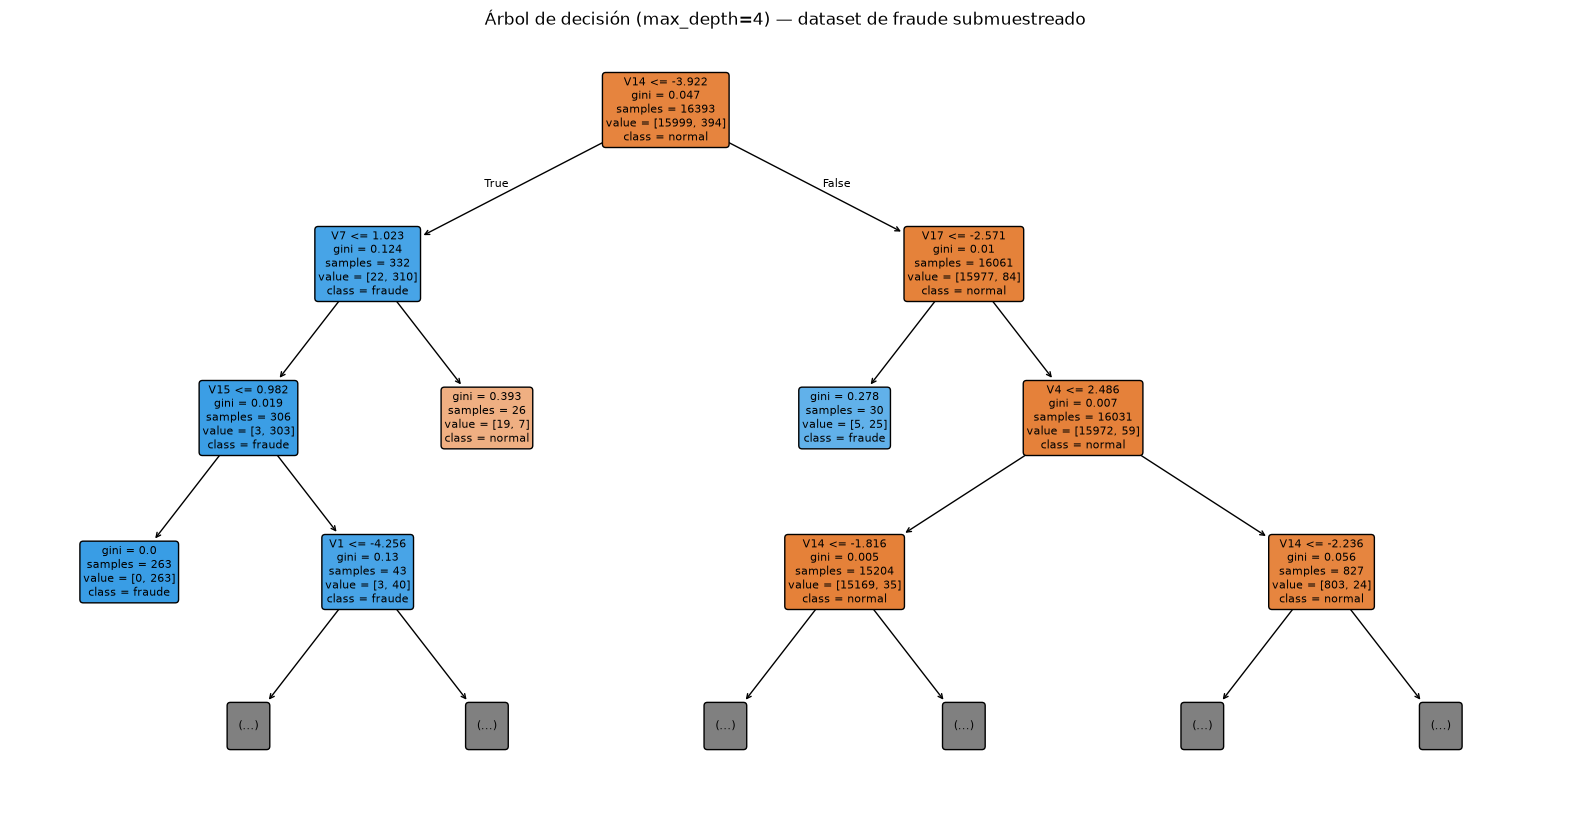

In [8]:

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=["normal", "fraude"],
    filled=True,
    rounded=True,
    max_depth=3,          # limitamos lo que se dibuja para que sea legible
    fontsize=8,
    ax=ax,
)
ax.set_title("Árbol de decisión (max_depth=4) — dataset de fraude submuestreado")
plt.show()


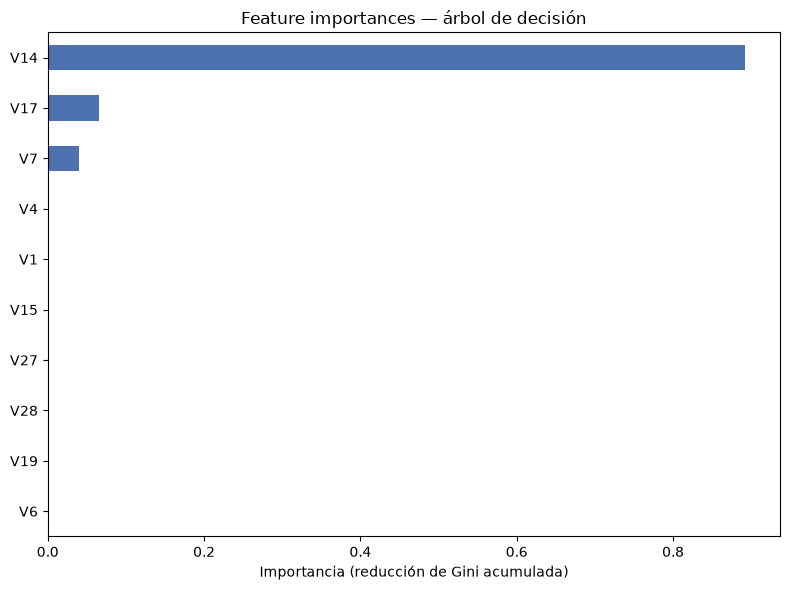

V14    0.892203
V17    0.065256
V7     0.039437
V4     0.001773
V1     0.000762
V15    0.000570
V6     0.000000
V19    0.000000
V28    0.000000
V27    0.000000
dtype: float64

In [9]:

importancias = pd.Series(arbol.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.head(10).sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_title("Feature importances — árbol de decisión")
ax.set_xlabel("Importancia (reducción de Gini acumulada)")
plt.tight_layout()
plt.show()

importancias.head(10)



Nota: `feature_importances_` en scikit-learn mide, para cada variable, la
reducción total de impureza (Gini) que aporta en todos los nodos donde se
usó, ponderada por la proporción de muestras que pasan por ese nodo. Es una
medida útil pero **no es causal** (no implica que la variable "cause" el
fraude).

---



## 2. Métodos de ensamble

Un árbol individual es fácil de interpretar pero **inestable**: pequeños
cambios en los datos de entrenamiento pueden producir árboles muy distintos
(alta varianza). Los métodos de ensamble combinan **muchos** modelos
"débiles" (usualmente árboles) para obtener un modelo agregado más robusto.
El objetivo general de un ensamble es reducir **varianza**, **sesgo**, o
ambos, dependiendo de la estrategia.

### 2.1 Bagging (Bootstrap Aggregating)

1. Se generan $B$ muestras **bootstrap** (muestreo con reemplazo, mismo
   tamaño que el dataset original) a partir del set de entrenamiento.
2. Se entrena un modelo (típicamente un árbol) en cada muestra bootstrap,
   de forma **independiente** (se pueden entrenar en paralelo).
3. La predicción final se agrega:
   - **Regresión**: promedio de las $B$ predicciones.
   - **Clasificación**: voto mayoritario (o promedio de probabilidades).

Bagging reduce principalmente la **varianza** del modelo, porque promediar
muchos modelos con errores no perfectamente correlacionados cancela parte
del ruido individual de cada uno.

### 2.2 Random Forest

Random Forest es bagging aplicado a árboles, con un ingrediente adicional de
aleatoriedad: **en cada split**, en lugar de buscar la variable "óptima"
entre *todas* las variables disponibles, el algoritmo busca la mejor entre
un **subconjunto aleatorio de $m$ variables** (típicamente $m \approx
\sqrt{p}$ para clasificación, con $p$ = número total de variables).

Esta doble aleatoriedad (bootstrap de filas + subconjunto aleatorio de
columnas en cada split) **decorrelaciona** los árboles del ensamble entre sí,
lo que reduce la varianza más de lo que lograría bagging por sí solo (si
todos los árboles tienden a usar la misma variable "fuerte" en la raíz,
estarían muy correlacionados y promediarlos ayudaría menos).

**Ventajas**: robusto a ruido y outliers, funciona bien en datasets grandes
y de alta dimensión, entrega una medida de *feature importance*, requiere
poco tuning para obtener un buen desempeño de partida.

**Desventajas**: pierde la interpretabilidad directa de un árbol individual
(ya no se puede "leer" el modelo como una serie de reglas simples); más
costoso computacionalmente que un solo árbol.

### 2.3 Boosting / Gradient Boosting

A diferencia de bagging (árboles entrenados **en paralelo**, de forma
independiente), en **boosting** los árboles se entrenan **secuencialmente**:
cada nuevo árbol se enfoca en corregir los errores (residuales) del ensamble
construido hasta el momento.

En **Gradient Boosting** específicamente, esto se formaliza como un
**descenso de gradiente en el espacio de funciones**: en cada iteración se
ajusta un nuevo árbol a (una aproximación de) el gradiente negativo de la
función de pérdida respecto a las predicciones actuales del ensamble, y se
suma al ensamble con un factor de aprendizaje (`learning_rate`) pequeño.

Boosting tiende a reducir tanto **sesgo** como **varianza**, pero es más
sensible a overfitting si se usan demasiadas iteraciones o un
`learning_rate` demasiado alto, y al ser secuencial es más difícil de
paralelizar que bagging.

> **Nota — XGBoost / LightGBM / CatBoost:** estas son implementaciones
> optimizadas de gradient boosting (histogram binning, manejo nativo de
> categóricas, regularización adicional, paralelización a nivel de split,
> soporte de GPU, etc.) que se han convertido en **estado del arte en la
> industria** para datos tabulares, ganando sistemáticamente competencias de
> Kaggle y usándose en producción en muchas empresas. En este curso **no las
> instalamos** (requieren dependencias de sistema como `libomp` que no están
> garantizadas en todas las máquinas); en su lugar usamos
> `HistGradientBoostingClassifier` de scikit-learn, que implementa la misma
> idea central (gradient boosting con *histogram binning*, inspirado
> directamente en LightGBM) sin dependencias externas.

### 2.4 Demo: Random Forest y Gradient Boosting sobre el dataset de fraude


In [10]:

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

print("== Random Forest ==")
print(classification_report(y_test, y_pred_rf, digits=3, target_names=["normal", "fraude"]))
print("== Gradient Boosting (HistGradientBoostingClassifier) ==")
print(classification_report(y_test, y_pred_hgb, digits=3, target_names=["normal", "fraude"]))


== Random Forest ==
              precision    recall  f1-score   support

      normal      0.996     1.000     0.998      4001
      fraude      0.988     0.827     0.900        98

    accuracy                          0.996      4099
   macro avg      0.992     0.913     0.949      4099
weighted avg      0.996     0.996     0.995      4099

== Gradient Boosting (HistGradientBoostingClassifier) ==
              precision    recall  f1-score   support

      normal      0.995     1.000     0.997      4001
      fraude      0.975     0.806     0.883        98

    accuracy                          0.995      4099
   macro avg      0.985     0.903     0.940      4099
weighted avg      0.995     0.995     0.995      4099



In [11]:

def resumen_metricas(nombre, y_true, y_pred, y_score=None):
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_score) if y_score is not None else np.nan,
    }

comparacion = pd.DataFrame([
    resumen_metricas("Árbol de decisión", y_test, y_pred_arbol, arbol.predict_proba(X_test)[:, 1]),
    resumen_metricas("Random Forest", y_test, y_pred_rf, rf.predict_proba(X_test)[:, 1]),
    resumen_metricas("Gradient Boosting", y_test, y_pred_hgb, hgb.predict_proba(X_test)[:, 1]),
]).set_index("modelo")

comparacion.round(3)


,accuracy,precision,recall,f1,pr_auc
modelo,,,,,
Árbol de decisión,0.994,0.952,0.806,0.873,0.809
Random Forest,0.996,0.988,0.827,0.900,0.895
Gradient Boosting,0.995,0.975,0.806,0.883,0.903



Los ensambles (Random Forest y Gradient Boosting) típicamente superan al
árbol individual en recall/F1/PR-AUC, a costa de perder la interpretabilidad
directa del árbol simple.

---



## 3. Ajuste de hiperparámetros

Hasta ahora usamos los hiperparámetros por defecto (o elegidos "a ojo") de
Random Forest y Gradient Boosting. En la práctica se busca la combinación de
hiperparámetros que optimiza una métrica de validación cruzada. Dos
herramientas disponibles en scikit-learn:

- **`GridSearchCV`**: prueba **todas** las combinaciones de una grilla de
  hiperparámetros. Exhaustivo pero costoso si el espacio de búsqueda es
  grande (crece exponencialmente con el número de hiperparámetros).
- **`RandomizedSearchCV`**: en lugar de probar todas las combinaciones,
  muestrea aleatoriamente un número fijo (`n_iter`) de combinaciones desde
  las distribuciones especificadas. Casi siempre encuentra una combinación
  casi tan buena como grid search completo, con mucho menos cómputo,
  especialmente cuando algunos hiperparámetros importan poco.

> **Nota conceptual — Optuna y optimización bayesiana:** existen librerías
> especializadas de optimización de hiperparámetros, como **Optuna**, que
> usan un enfoque *define-by-run* (el espacio de búsqueda se define
> dinámicamente en código Python, permitiendo condicionales entre
> hiperparámetros) y algoritmos de **optimización bayesiana** como el
> **TPE (Tree-structured Parzen Estimator)**: en vez de muestrear
> combinaciones al azar (como `RandomizedSearchCV`), TPE modela
> probabilísticamente qué regiones del espacio de hiperparámetros tienden a
> dar mejores resultados, y concentra las siguientes pruebas ahí, siendo más
   eficiente que una búsqueda aleatoria pura. Optuna **no está instalada en
   este proyecto** (no es una dependencia del curso); el ejercicio práctico
   de esta sesión se hace con `RandomizedSearchCV`, ya disponible en
   scikit-learn.

### 3.1 Demo: `RandomizedSearchCV` sobre Random Forest


In [12]:

from scipy.stats import randint

param_distributions = {
    "n_estimators": randint(100, 400),
    "max_depth": [None, 4, 8, 12, 16],
    "min_samples_leaf": randint(1, 20),
    "max_features": ["sqrt", "log2", None],
}

busqueda = RandomizedSearchCV(
    # n_jobs=-1 va en la búsqueda (paraleliza combinaciones de hiperparámetros);
    # dejamos el estimador base en n_jobs=1 para evitar paralelismo anidado.
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=param_distributions,
    n_iter=15,
    scoring="average_precision",   # PR-AUC: apropiada para clases desbalanceadas
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
busqueda.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(busqueda.best_params_)
print(f"Mejor PR-AUC en validación cruzada: {busqueda.best_score_:.3f}")


Mejores hiperparámetros encontrados:
{'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 6, 'n_estimators': 153}
Mejor PR-AUC en validación cruzada: 0.898


In [13]:

rf_tuned = busqueda.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)

comparacion.loc["Random Forest (RandomizedSearchCV)"] = resumen_metricas(
    "Random Forest (RandomizedSearchCV)",
    y_test, y_pred_rf_tuned, rf_tuned.predict_proba(X_test)[:, 1],
)
comparacion.round(3)


,accuracy,precision,recall,f1,pr_auc
modelo,,,,,
Árbol de decisión,0.994,0.952,0.806,0.873,0.809
Random Forest,0.996,0.988,0.827,0.900,0.895
Gradient Boosting,0.995,0.975,0.806,0.883,0.903
Random Forest (RandomizedSearchCV),0.995,0.988,0.816,0.894,0.893



---



## 4. Desbalance de clases

### 4.1 Motivación: un caso real

Un caso mencionado en clase: una empresa de energía eléctrica quiere predecir
la **probabilidad de falla** en cada zona/hora, para asignar de forma
preventiva las brigadas de reparación disponibles. En este tipo de problema,
la proporción de casos positivos (falla real) suele ser de apenas **~1.8%**
de las observaciones: la inmensa mayoría de las combinaciones zona-hora no
presentan falla.

Nuestro dataset de fraude submuestreado tiene una situación análoga: ~2.4%
de casos positivos. Vamos a ver por qué esto rompe la intuición habitual de
usar **accuracy** como métrica de desempeño.

### 4.2 Por qué accuracy engaña

Un modelo que **predice "0" siempre**, sin mirar ni una sola variable, ya
tiene una accuracy muy alta simplemente porque la clase mayoritaria domina
el dataset. Verifiquémoslo:


In [14]:

dummy = DummyClassifier(strategy="constant", constant=0)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"Accuracy del clasificador 'todo es 0': {accuracy_score(y_test, y_pred_dummy):.4f}")
print(classification_report(y_test, y_pred_dummy, digits=3, target_names=["normal", "fraude"], zero_division=0))


Accuracy del clasificador 'todo es 0': 0.9761
              precision    recall  f1-score   support

      normal      0.976     1.000     0.988      4001
      fraude      0.000     0.000     0.000        98

    accuracy                          0.976      4099
   macro avg      0.488     0.500     0.494      4099
weighted avg      0.953     0.976     0.964      4099




El clasificador "todo es 0" tiene ~97.6% de accuracy (igual al porcentaje de
la clase mayoritaria) pero **recall = 0** sobre la clase de interés
(fraude): nunca detecta ni un solo fraude. En un caso real de brigadas de
reparación, este modelo sería inútil (nunca despacharía una brigada), a
pesar de su accuracy aparentemente excelente.

Por eso, en problemas desbalanceados usamos métricas que sí reflejan el
desempeño sobre la clase minoritaria:

- **Precision**: de las veces que predije positivo, ¿cuántas eran realmente
  positivas?
- **Recall**: de todos los positivos reales, ¿cuántos detecté?
- **F1**: media armónica de precision y recall.
- **PR-AUC** (área bajo la curva Precision-Recall): resume el trade-off
  precision/recall en todos los umbrales de decisión posibles; es más
  informativa que el AUC-ROC tradicional cuando la clase positiva es rara.

### 4.3 Técnicas de balanceo

- **Random Undersampling**: elimina aleatoriamente muestras de la clase
  mayoritaria hasta emparejar (o acercar) su tamaño al de la clase
  minoritaria. Ventaja: rápido y simple. Desventaja: se descarta información
  potencialmente útil de la clase mayoritaria.
- **Random Oversampling**: duplica aleatoriamente muestras de la clase
  minoritaria (con reemplazo) hasta emparejar su tamaño al de la mayoritaria.
  Ventaja: no se pierde información de la clase mayoritaria. Desventaja:
  puede favorecer overfitting sobre las mismas observaciones minoritarias
  repetidas.
- **Tomek Links**: identifica pares de observaciones de clases opuestas que
  son **mutuamente el vecino más cercano** entre sí (es decir, ninguna otra
  observación está más cerca de ninguna de las dos). Estos pares suelen
  estar en la frontera de decisión o representar ruido; se elimina la
  observación de la clase **mayoritaria** de cada par, "limpiando" la
  frontera entre clases (a diferencia del undersampling puro al azar, que no
  mira dónde están las observaciones).
- **NearMiss**: variante de undersampling *informado*, que en vez de
  eliminar al azar conserva las observaciones de la clase mayoritaria más
  cercanas (o con ciertos criterios de distancia) a la clase minoritaria,
  buscando mantener los casos "difíciles"/informativos de la frontera de
  decisión.

Implementamos versiones simples de undersampling y oversampling con pandas
(no usamos la librería `imbalanced-learn`, que no está instalada en el
proyecto, para evitar riesgos de instalación en las máquinas de los
estudiantes).

### 4.4 Demo: undersampling manual


In [15]:

train_bal = X_train.copy()
train_bal["Class"] = y_train.values

mayoritaria = train_bal[train_bal["Class"] == 0]
minoritaria = train_bal[train_bal["Class"] == 1]

print(f"Antes  -> mayoritaria: {len(mayoritaria)}, minoritaria: {len(minoritaria)}")

mayoritaria_under = mayoritaria.sample(n=len(minoritaria), random_state=RANDOM_STATE)
train_under = pd.concat([mayoritaria_under, minoritaria]).sample(frac=1.0, random_state=RANDOM_STATE)

print(f"Después -> mayoritaria: {len(mayoritaria_under)}, minoritaria: {len(minoritaria)}")

X_train_under = train_under.drop(columns=["Class"])
y_train_under = train_under["Class"]


Antes  -> mayoritaria: 15999, minoritaria: 394
Después -> mayoritaria: 394, minoritaria: 394


In [16]:

rf_under = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
rf_under.fit(X_train_under, y_train_under)
y_pred_rf_under = rf_under.predict(X_test)

print(classification_report(y_test, y_pred_rf_under, digits=3, target_names=["normal", "fraude"]))


              precision    recall  f1-score   support

      normal      0.997     0.979     0.988      4001
      fraude      0.506     0.878     0.642        98

    accuracy                          0.977      4099
   macro avg      0.751     0.928     0.815      4099
weighted avg      0.985     0.977     0.980      4099



### 4.5 Demo: oversampling manual

In [17]:

minoritaria_over = minoritaria.sample(n=len(mayoritaria), replace=True, random_state=RANDOM_STATE)
train_over = pd.concat([mayoritaria, minoritaria_over]).sample(frac=1.0, random_state=RANDOM_STATE)

print(f"Después de oversampling -> mayoritaria: {len(mayoritaria)}, minoritaria (con repetición): {len(minoritaria_over)}")

X_train_over = train_over.drop(columns=["Class"])
y_train_over = train_over["Class"]

rf_over = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
rf_over.fit(X_train_over, y_train_over)
y_pred_rf_over = rf_over.predict(X_test)

print(classification_report(y_test, y_pred_rf_over, digits=3, target_names=["normal", "fraude"]))


Después de oversampling -> mayoritaria: 15999, minoritaria (con repetición): 15999


              precision    recall  f1-score   support

      normal      0.996     1.000     0.998      4001
      fraude      0.988     0.827     0.900        98

    accuracy                          0.996      4099
   macro avg      0.992     0.913     0.949      4099
weighted avg      0.996     0.996     0.995      4099



### 4.6 Comparación antes / después del balanceo

In [18]:

comparacion_balanceo = pd.DataFrame([
    resumen_metricas("RF (datos originales, desbalanceados)", y_test, y_pred_rf, rf.predict_proba(X_test)[:, 1]),
    resumen_metricas("RF + undersampling", y_test, y_pred_rf_under, rf_under.predict_proba(X_test)[:, 1]),
    resumen_metricas("RF + oversampling", y_test, y_pred_rf_over, rf_over.predict_proba(X_test)[:, 1]),
]).set_index("modelo")

comparacion_balanceo.round(3)


,accuracy,precision,recall,f1,pr_auc
modelo,,,,,
"RF (datos originales, desbalanceados)",0.996,0.988,0.827,0.900,0.895
RF + undersampling,0.977,0.506,0.878,0.642,0.894
RF + oversampling,0.996,0.988,0.827,0.900,0.909



Observa que el accuracy apenas cambia entre las tres variantes (siempre va a
ser alto porque la clase mayoritaria domina el test set), pero **recall**,
**F1** y **PR-AUC** sí cambian de forma más notoria: el balanceo típicamente
mejora el recall (detectamos más fraudes reales) aunque puede sacrificar algo
de precision (más falsas alarmas). Cuál balance es preferible depende del
costo de negocio de cada tipo de error (un fraude no detectado vs. una
transacción legítima marcada como sospechosa).

---



## 5. Ejercicios de práctica

Los siguientes ejercicios usan el mismo dataset de fraude submuestreado
(`X_train`, `X_test`, `y_train`, `y_test`) ya cargado arriba. Intenta
resolverlos antes de mirar la solución.

### Ejercicio 1 — Profundidad del árbol y overfitting

Entrena tres `DecisionTreeClassifier` con `max_depth` en `{2, 6, None}`
(`None` = sin límite de profundidad). Para cada uno, calcula F1 **en train**
y F1 **en test**. Grafica (o imprime en una tabla) cómo cambia la brecha
train/test a medida que el árbol crece: ¿en qué punto empieza a verse
overfitting (F1 en train mucho más alto que F1 en test)?


In [19]:

# TODO: entrena DecisionTreeClassifier con max_depth en [2, 6, None]
# TODO: calcula f1_score en train y test para cada uno
# TODO: arma una tabla/gráfico comparando la brecha train-test


### Solución 1

In [20]:

resultados_profundidad = []
for profundidad in [2, 6, None]:
    arbol_p = DecisionTreeClassifier(max_depth=profundidad, random_state=RANDOM_STATE)
    arbol_p.fit(X_train, y_train)

    f1_train = f1_score(y_train, arbol_p.predict(X_train))
    f1_test = f1_score(y_test, arbol_p.predict(X_test))

    resultados_profundidad.append({
        "max_depth": profundidad if profundidad is not None else "sin límite",
        "f1_train": f1_train,
        "f1_test": f1_test,
        "brecha (train - test)": f1_train - f1_test,
    })

pd.DataFrame(resultados_profundidad)


,max_depth,f1_train,f1_test,brecha (train - test)
0,2,0.905405,0.895028,0.010378
1,6,0.933694,0.888889,0.044805
2,sin límite,1.000000,0.849741,0.150259



A medida que `max_depth` crece (o se deja sin límite), el F1 en train tiende
a subir hacia 1.0 (el árbol memoriza el training set), mientras que el F1 en
test se estanca o incluso empeora: la brecha train-test creciente es la
señal clásica de overfitting, y es exactamente lo que el pre-pruning
(`max_depth` limitado) busca evitar.

### Ejercicio 2 — Curvas Precision-Recall superpuestas: Random Forest vs. Gradient Boosting

Usando los modelos `rf` y `hgb` ya entrenados arriba, calcula la curva
Precision-Recall de cada uno sobre el test set (`precision_recall_curve`) y
grafícalas **superpuestas** en el mismo eje, incluyendo el PR-AUC de cada
modelo en la leyenda. ¿Cuál domina al otro en la mayoría de los niveles de
recall?


In [21]:

# TODO: calcula precision_recall_curve para rf y hgb sobre el test set
# TODO: grafica ambas curvas superpuestas con matplotlib, con el PR-AUC en la leyenda


### Solución 2

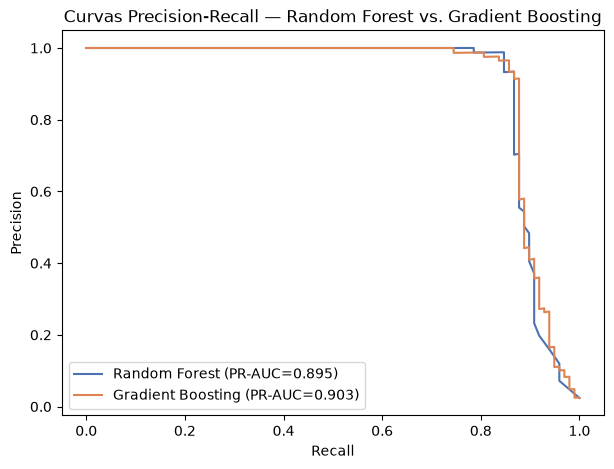

In [22]:

prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf.predict_proba(X_test)[:, 1])
prec_hgb, rec_hgb, _ = precision_recall_curve(y_test, hgb.predict_proba(X_test)[:, 1])

pr_auc_rf = average_precision_score(y_test, rf.predict_proba(X_test)[:, 1])
pr_auc_hgb = average_precision_score(y_test, hgb.predict_proba(X_test)[:, 1])

fig, ax = plt.subplots()
ax.plot(rec_rf, prec_rf, label=f"Random Forest (PR-AUC={pr_auc_rf:.3f})", color="#4C72B0")
ax.plot(rec_hgb, prec_hgb, label=f"Gradient Boosting (PR-AUC={pr_auc_hgb:.3f})", color="#DD8452")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curvas Precision-Recall — Random Forest vs. Gradient Boosting")
ax.legend()
plt.show()



### Ejercicio 3 — Undersampling informado (Tomek Links) vs. undersampling aleatorio

Implementa una versión simple de **Tomek Links** sobre `X_train`/`y_train`:
para cada observación de la clase minoritaria, encuentra su vecino más
cercano (usa `NearestNeighbors` de scikit-learn sobre variables
estandarizadas); si ese vecino más cercano pertenece a la clase mayoritaria
**y** la observación minoritaria es también el vecino más cercano de ese
vecino (es decir, son mutuamente el vecino más cercano el uno del otro),
entonces esa pareja forma un Tomek Link: elimina la observación
**mayoritaria** del link. Entrena un Random Forest sobre el training set
resultante y compara sus métricas contra el undersampling aleatorio de la
sección 4.4 (F1, recall, PR-AUC).


In [23]:

# TODO: estandariza las variables (ej. StandardScaler) para calcular distancias
# TODO: usa NearestNeighbors para encontrar, para cada punto, su vecino más cercano
# TODO: identifica los Tomek Links (pares mutuamente más cercanos de clases opuestas)
# TODO: elimina las observaciones mayoritarias que forman parte de un Tomek Link
# TODO: entrena un RandomForestClassifier sobre ese training set y compara métricas


### Solución 3

In [24]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# vecino más cercano de cada observación (excluyendo ella misma)
nn = NearestNeighbors(n_neighbors=2, n_jobs=-1).fit(X_train_scaled)
_, indices_vecinos = nn.kneighbors(X_train_scaled)
vecino_mas_cercano = indices_vecinos[:, 1]  # columna 0 es la propia observación

y_train_arr = y_train.to_numpy()
es_tomek_link = np.zeros(len(y_train_arr), dtype=bool)

for i in range(len(y_train_arr)):
    j = vecino_mas_cercano[i]
    # clases opuestas y mutuamente vecinos más cercanos
    if y_train_arr[i] != y_train_arr[j] and vecino_mas_cercano[j] == i:
        es_tomek_link[i] = True

# de cada Tomek Link, se elimina la observación de la clase MAYORITARIA (Class == 0)
eliminar = es_tomek_link & (y_train_arr == 0)
print(f"Tomek Links encontrados (observaciones mayoritarias a eliminar): {eliminar.sum()}")

X_train_tomek = X_train.loc[~eliminar]
y_train_tomek = y_train.loc[~eliminar]

print(f"Tamaño del training set: original={len(y_train)}, tras Tomek Links={len(y_train_tomek)}")

rf_tomek = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
rf_tomek.fit(X_train_tomek, y_train_tomek)
y_pred_rf_tomek = rf_tomek.predict(X_test)

comparacion_tomek = pd.DataFrame([
    resumen_metricas("RF + undersampling aleatorio", y_test, y_pred_rf_under, rf_under.predict_proba(X_test)[:, 1]),
    resumen_metricas("RF + Tomek Links", y_test, y_pred_rf_tomek, rf_tomek.predict_proba(X_test)[:, 1]),
]).set_index("modelo")

comparacion_tomek.round(3)


Tomek Links encontrados (observaciones mayoritarias a eliminar): 11
Tamaño del training set: original=16393, tras Tomek Links=16382


,accuracy,precision,recall,f1,pr_auc
modelo,,,,,
RF + undersampling aleatorio,0.977,0.506,0.878,0.642,0.894
RF + Tomek Links,0.996,0.988,0.827,0.900,0.894



A diferencia del undersampling aleatorio (que elimina muestras al azar de la
clase mayoritaria sin importar dónde estén), Tomek Links solo elimina
observaciones mayoritarias que están **justo en la frontera** con la clase
minoritaria, "limpiando" el borde de decisión sin descartar tantas
observaciones típicas/representativas de la clase mayoritaria. En la
práctica suele eliminar muchas menos observaciones que un undersampling
agresivo (por eso a menudo se combina con oversampling, no se usa solo).

---



## 6. Resumen y cierre

En esta sesión vimos:

1. **Árboles de decisión**: particionan el espacio de entrada usando Gini o
   Entropía (clasificación) / varianza (regresión) como función de costo;
   son interpretables y no requieren normalización, pero necesitan
   regularización (pre-pruning o post-pruning) para no sobreajustar.
2. **Métodos de ensamble**: bagging (Random Forest) entrena árboles en
   paralelo sobre muestras bootstrap + subconjuntos aleatorios de variables
   para reducir varianza; boosting (Gradient Boosting / XGBoost / LightGBM /
   CatBoost) entrena árboles secuencialmente, cada uno corrigiendo los
   errores del ensamble anterior.
3. **Ajuste de hiperparámetros**: `GridSearchCV` (exhaustivo) y
   `RandomizedSearchCV` (muestreo aleatorio, más eficiente); herramientas
   como Optuna llevan esta idea más lejos con optimización bayesiana (TPE).
4. **Desbalance de clases**: accuracy es engañosa cuando la clase positiva
   es rara; hay que evaluar con precision, recall, F1 y PR-AUC, y se puede
   mitigar el desbalance con undersampling, oversampling, Tomek Links o
   NearMiss.

### Conexión con el Taller grupal

El **Taller grupal** del curso (predicción de accidentalidad vial, un
problema con clases fuertemente desbalanceadas: la mayoría de las
combinaciones espacio-tiempo NO tienen accidente) usa **exactamente** las
técnicas de esta sesión: árboles/ensambles como modelos base, ajuste de
hiperparámetros, y balanceo de clases evaluado con métricas apropiadas
(F1/recall/PR-AUC en vez de accuracy). Esta sesión es la preparación directa
para ese trabajo — si entendiste el flujo completo aplicado al fraude, ya
tienes todo lo necesario para aplicarlo a accidentalidad.
